In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/podaci.csv")
df.head()

print("Provjera nedostajucih vrijednosti:")
print(df.isnull().sum())

num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
  print(f"\nUklanjanje {num_duplicates} duplikata.")
  df.drop_duplicates(inplace=True)
else:
  print("\nNema duplikata.")

# Prebacivanje razreda u numericku vrijednost, uklanjanje th (7th -> 7)

df['School_Grade'] = df['School_Grade'].astype(str).str.replace(r'th|st|nd|rd', '', regex=True)

# Pretvoriš u numerik, a ako nešto ne može da se pretvori, postane NaN (umesto da pukne kod)
df['School_Grade'] = pd.to_numeric(df['School_Grade'], errors='coerce')

# Tek onda popuniš NaN (ako ih ima) i pretvoriš u int
df['School_Grade'] = df['School_Grade'].fillna(0).astype(int)

# Izbacujemo Location jer ima previse unique vrijednosti, pa bismo dobili previse novih kolona, a i nema nam uticaja
df = df.drop(columns=['Location'])

# One-Hot encoding za kategroicke vrijednosti
categorical_cols = ['Gender', 'Phone_Usage_Purpose']

drop_first=True #je ključan da ne dupliramo informacije (npr. ako znamo da nije Muško i nije Ostalo, onda je Žensko)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Provjera rezultata
print(f"Nova dimenzija tabele: {df_encoded.shape}")
print("\nPrvih 5 redova enkodiranih podataka:")
display(df_encoded.head())

Provjera nedostajucih vrijednosti:
ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

Nema duplikata.
Nova dimenzija tabele: (3000, 28)

Prvih 5 redova enkodiranih podataka:


,ID,Name,Age,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level,Gender_Male,Gender_Other,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,1,Shannon Francis,13,9,4.0,6.1,78,5,0.1,10,...,1.2,4,8.7,10.0,False,False,False,False,False,False
1,2,Scott Rodriguez,17,7,5.5,6.5,70,5,0.0,3,...,1.8,2,5.3,10.0,False,False,False,False,False,False
2,3,Adrian Knox,13,11,5.8,5.5,93,8,0.8,2,...,0.4,6,5.7,9.2,False,True,True,False,False,False
3,4,Brittany Hamilton,18,12,3.1,3.9,78,8,1.6,9,...,0.8,8,3.0,9.8,False,False,False,False,False,True
4,5,Steven Smith,14,9,2.5,6.7,56,4,1.1,1,...,1.1,10,3.7,8.6,False,True,False,True,False,False


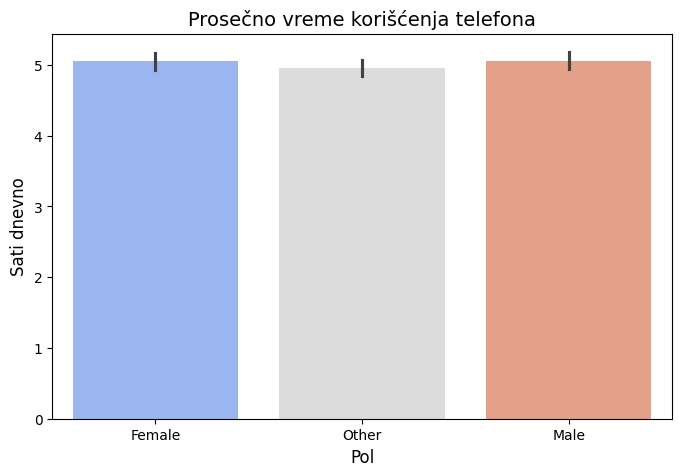

In [ ]:
# Bar plot: Prosečno vreme korišćenja telefona u odnosu na pol
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Gender', y='Daily_Usage_Hours', palette='coolwarm', hue='Gender', legend=False)
plt.title('Prosečno vreme korišćenja telefona', fontsize=14)
plt.ylabel('Sati dnevno', fontsize=12)
plt.xlabel('Pol', fontsize=12)
plt.show()

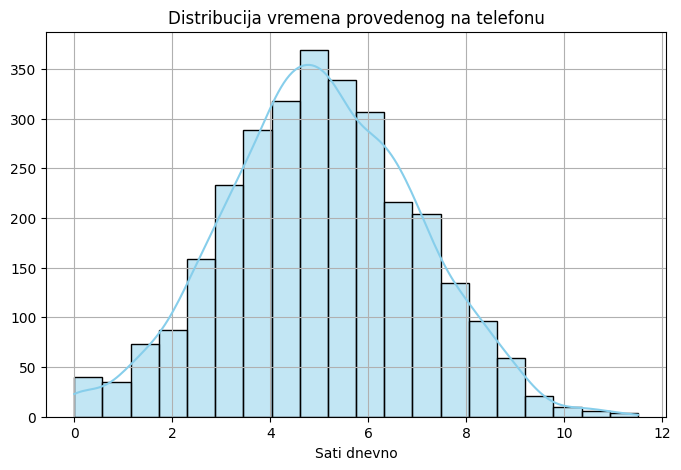

In [ ]:
# Distribucija koriscenja telefona Screen Time
plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Usage_Hours'], kde=True, bins=20, color='skyblue')
plt.title('Distribucija vremena provedenog na telefonu')
plt.xlabel('Sati dnevno')
plt.ylabel('')
plt.grid(True)
plt.show()

/tmp/ipython-input-1127280339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age', y='Time_on_Social_Media', palette='muted')


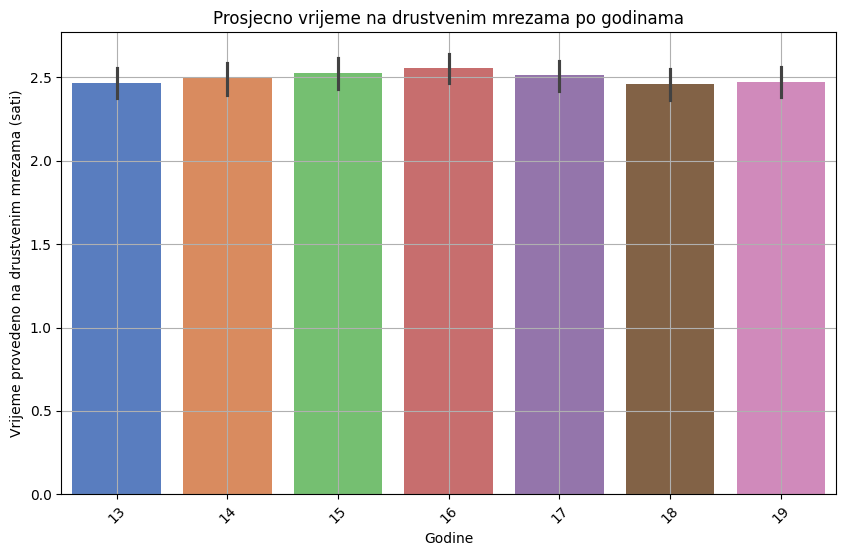

In [ ]:
# Vrijeme provedeno na drustvenim mrezama po godinama
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Age', y='Time_on_Social_Media', palette='muted')
plt.title('Prosjecno vrijeme na drustvenim mrezama po godinama')
plt.xlabel('Godine')
plt.ylabel('Vrijeme provedeno na drustvenim mrezama (sati)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

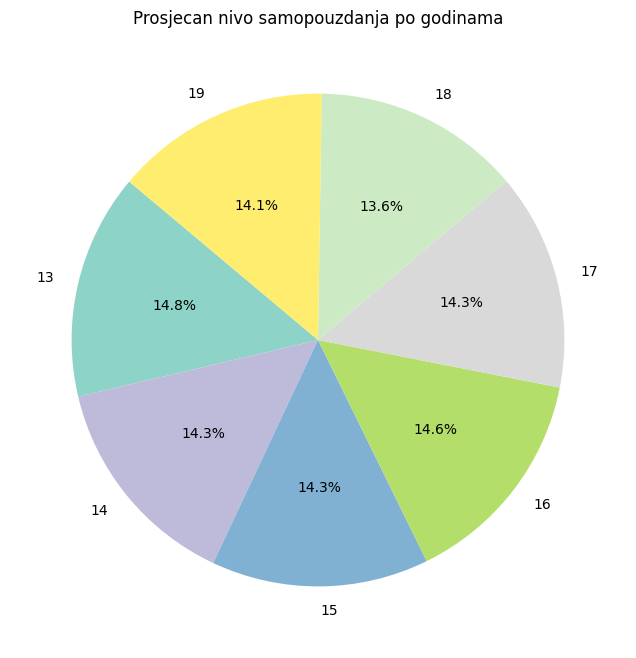

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Prosjecan nivo samopouzdanja po godinama
plt.figure(figsize=(8,8))

# Group by Age i izracnaj prosjecan Self_Esteem
age_self_esteem = df.groupby('Age')['Self_Esteem'].mean()

age_self_esteem.plot.pie(autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Prosjecan nivo samopouzdanja po godinama')
plt.ylabel('')
plt.show()

plt.figure(figsize=(10, 6))

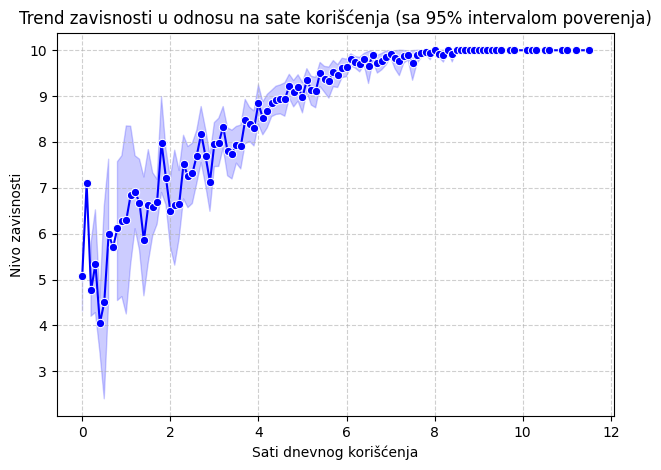

In [ ]:
# Seaborn ce sam izracunati prosek i dodati interval poverenja (senku).
sns.lineplot(data=df, x='Daily_Usage_Hours', y='Addiction_Level', marker='o', color='blue', errorbar=('ci', 95))

plt.title('Trend zavisnosti u odnosu na sate korišćenja (sa 95% intervalom poverenja)')
plt.xlabel('Sati dnevnog korišćenja')
plt.ylabel('Nivo zavisnosti')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

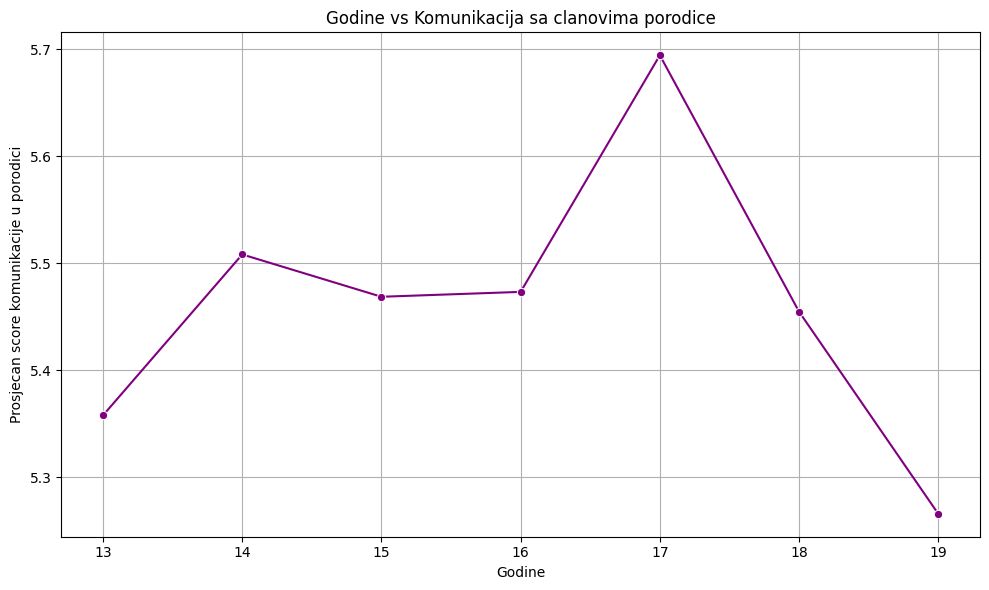

In [ ]:
# Group by Age da bi se dobio Family_Communication po godinama
grouped_df = df.groupby('Age')['Family_Communication'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Age', y='Family_Communication', marker='o', color='purple')
plt.title('Godine vs Komunikacija sa clanovima porodice')
plt.xlabel('Godine')
plt.ylabel('Prosjecan score komunikacije u porodici')
plt.grid(True)
plt.tight_layout()
plt.show()

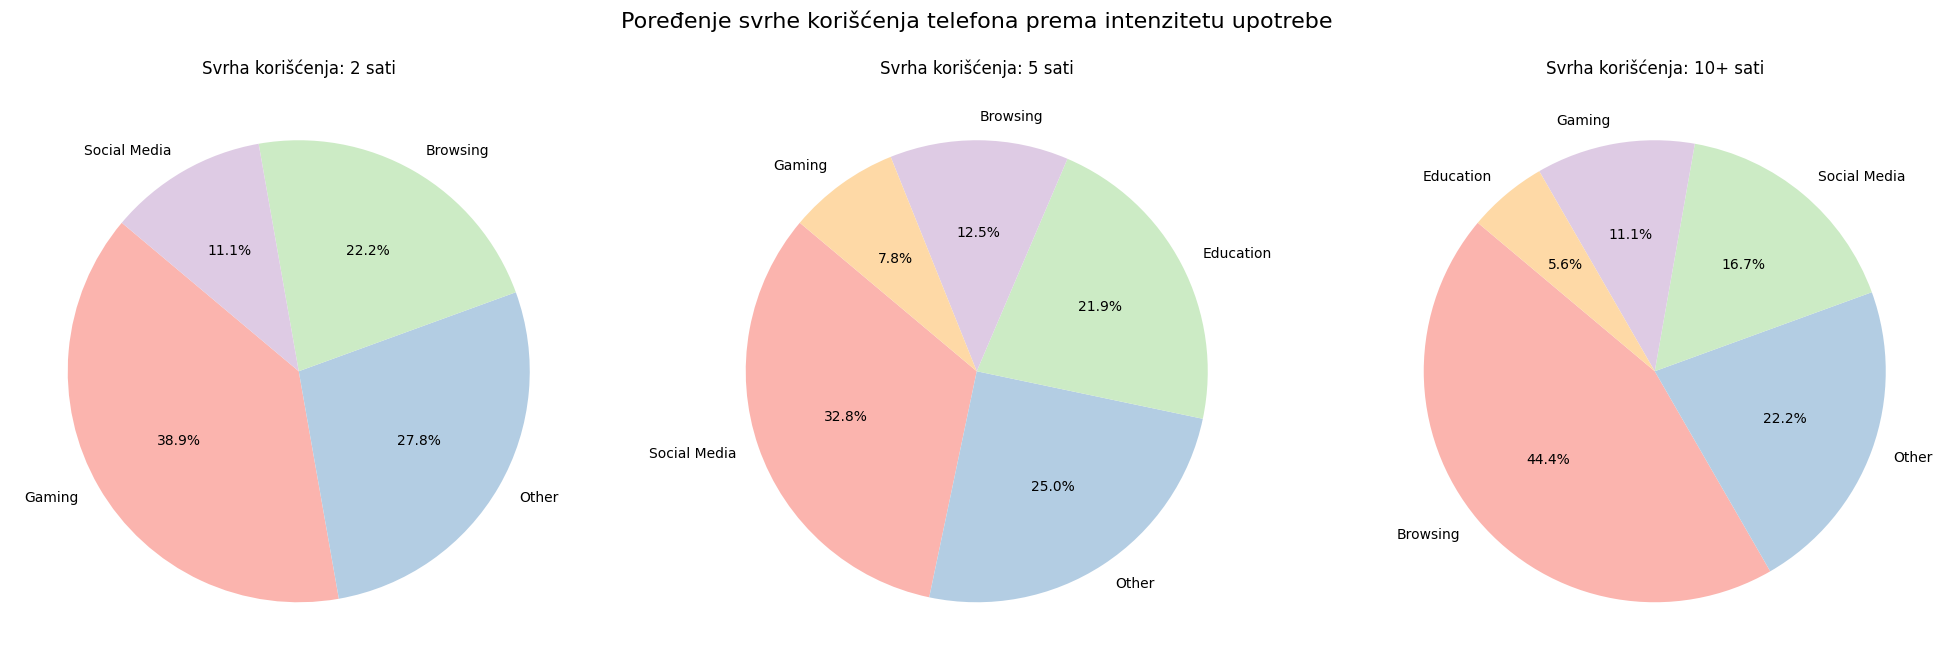

In [ ]:
# Svrhe koriscenja telefona - hipoteza o intenzitetu
hours_to_compare = [2, 5, 10] # 10 će nam služiti kao '10 i više'
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, hr in enumerate(hours_to_compare):
    if hr == 10:
        filtered_df = df[df['Daily_Usage_Hours'] >= 10]
        title_suffix = "10+ sati"
    else:
        filtered_df = df[df['Daily_Usage_Hours'] == hr]
        title_suffix = f"{hr} sati"

    counts = filtered_df['Phone_Usage_Purpose'].value_counts()

    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
                colors=plt.cm.Pastel1.colors)
    axes[i].set_title(f'Svrha korišćenja: {title_suffix}')

plt.suptitle('Poređenje svrhe korišćenja telefona prema intenzitetu upotrebe', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

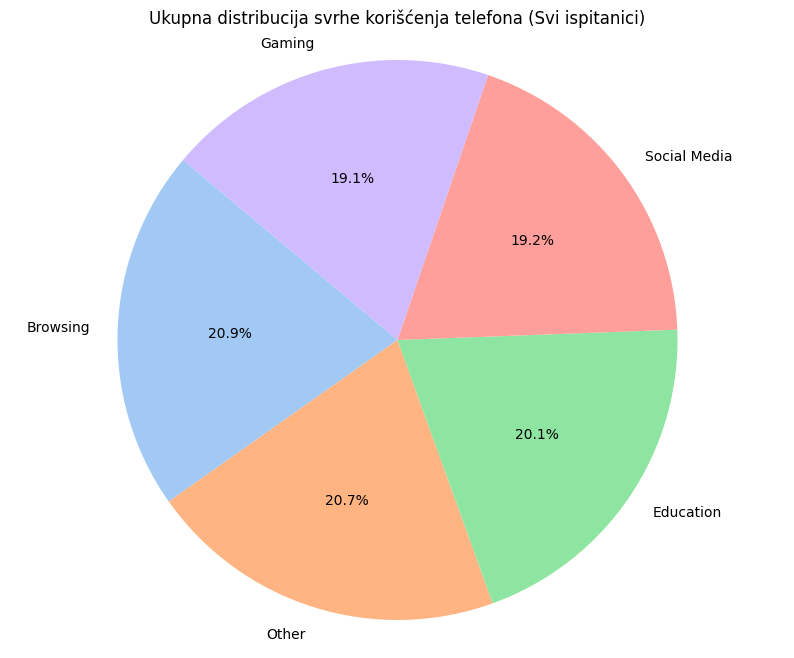

In [ ]:
# Izračunavanje ukupne distribucije
overall_counts = df['Phone_Usage_Purpose'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(overall_counts,
        labels=overall_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Ukupna distribucija svrhe korišćenja telefona (Svi ispitanici)')
plt.axis('equal')

plt.show()

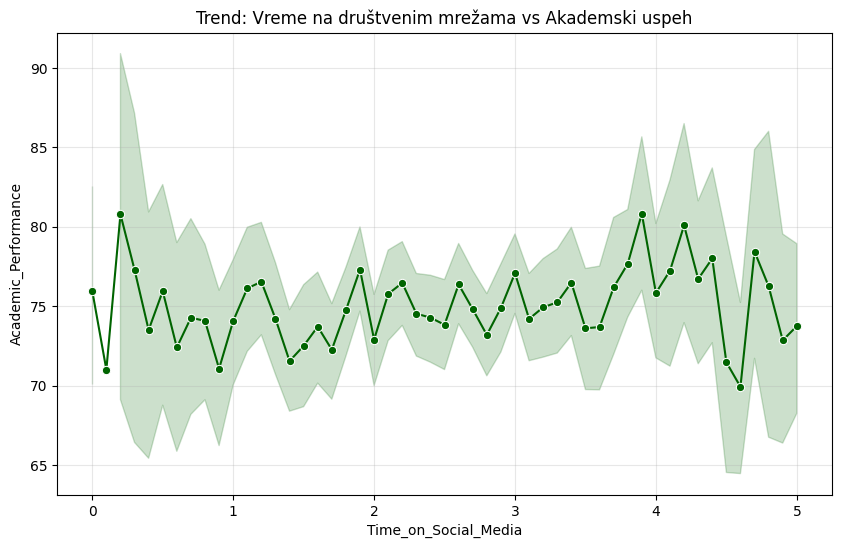

In [ ]:
# Uticaj vremena na drustvenim mrezama na usojeh u skoli
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time_on_Social_Media', y='Academic_Performance',
             marker='o', color='darkgreen', errorbar=('ci', 95))

plt.title('Trend: Vreme na društvenim mrežama vs Akademski uspeh')
plt.grid(True, alpha=0.3)
plt.show()

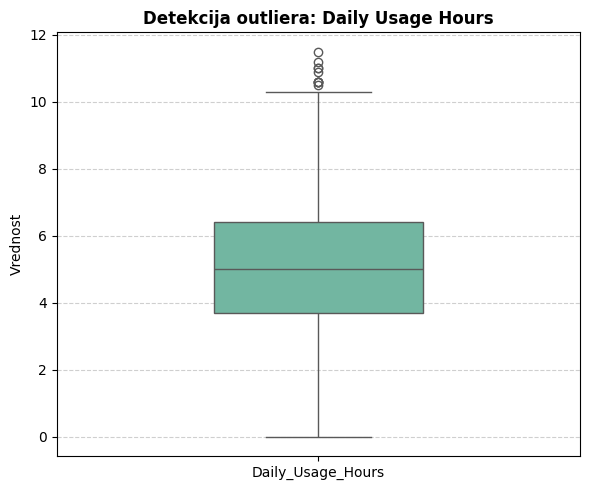

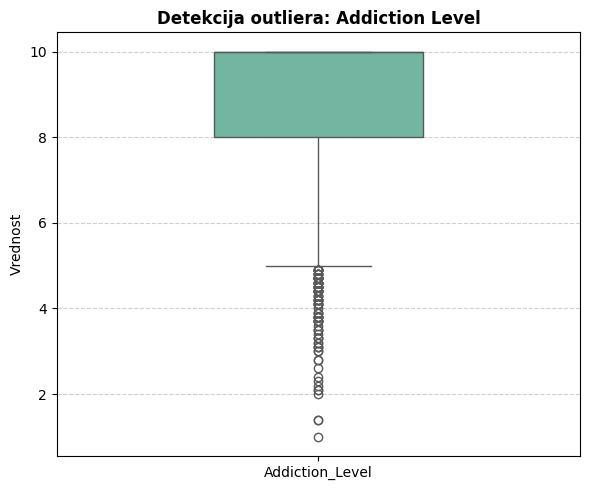

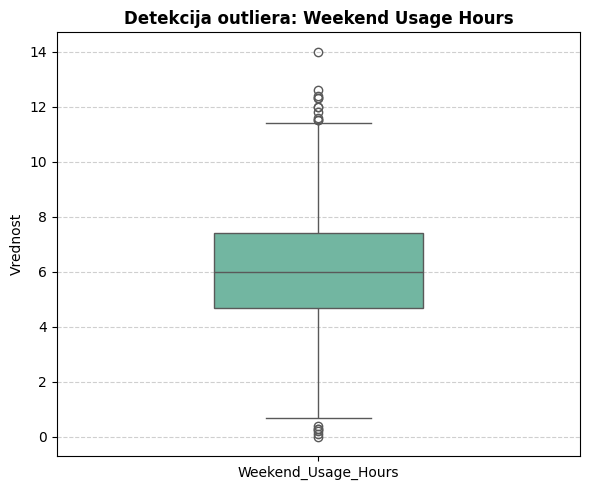

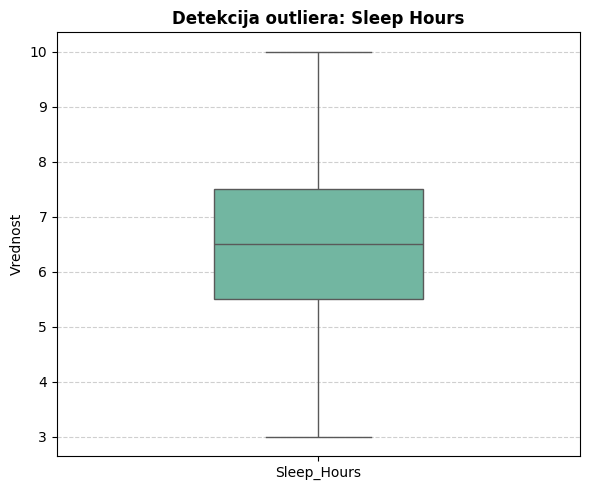

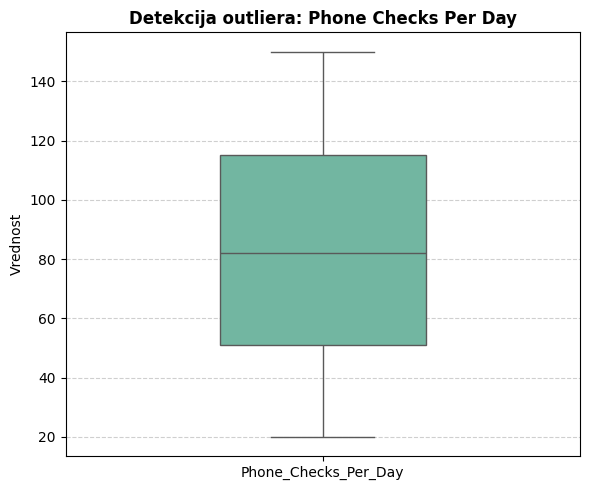

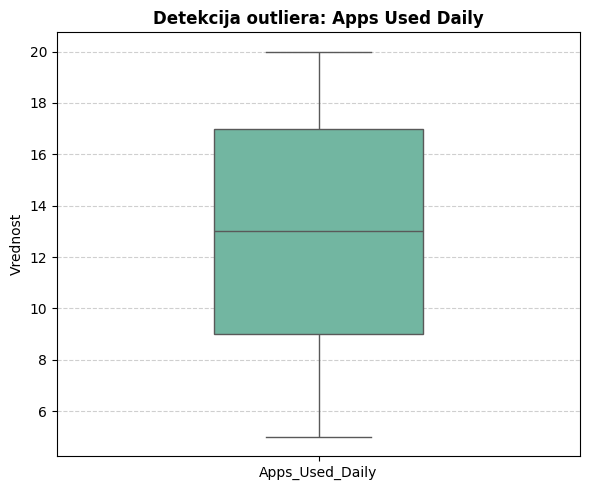

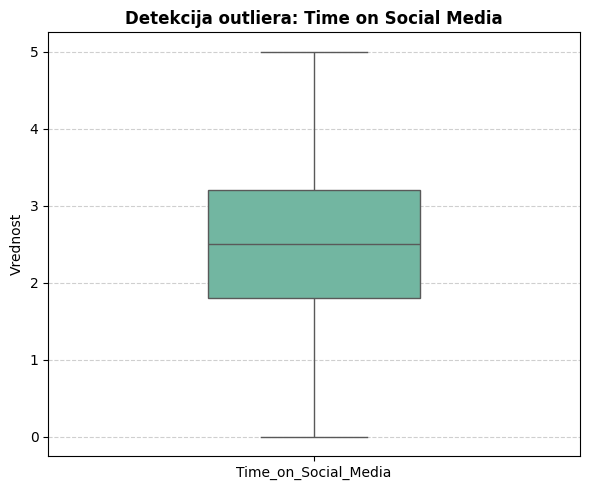

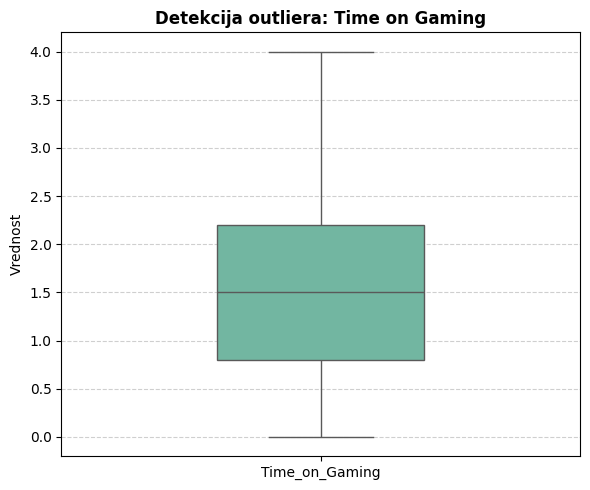

In [ ]:
# Box plotovi
def plot_single_boxplot(df, column_name):

    if column_name not in df.columns:
        print(f"Greška: Kolona '{column_name}' ne postoji u DataFrame-u.")
        return

    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Greška: Kolona '{column_name}' nije numerička i ne može se nacrtati boxplot.")
        return

    plt.figure(figsize=(6, 5))

    sns.boxplot(y=df[column_name],
                x=[column_name]*len(df),
                palette='Set2',
                width=0.4,
                hue=[column_name]*len(df),
                legend=False)

    clean_title = column_name.replace('_', ' ')
    plt.title(f'Detekcija outliera: {clean_title}', fontsize=12, fontweight='bold')
    plt.ylabel('Vrednost')
    plt.xlabel('') # Brišemo x-label jer je naziv već u naslovu
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_single_boxplot(df, 'Daily_Usage_Hours')
plot_single_boxplot(df, 'Addiction_Level')
plot_single_boxplot(df, 'Weekend_Usage_Hours')
plot_single_boxplot(df, 'Sleep_Hours')
plot_single_boxplot(df, 'Phone_Checks_Per_Day')
plot_single_boxplot(df, 'Apps_Used_Daily')
plot_single_boxplot(df, 'Time_on_Social_Media')
plot_single_boxplot(df, 'Time_on_Gaming')

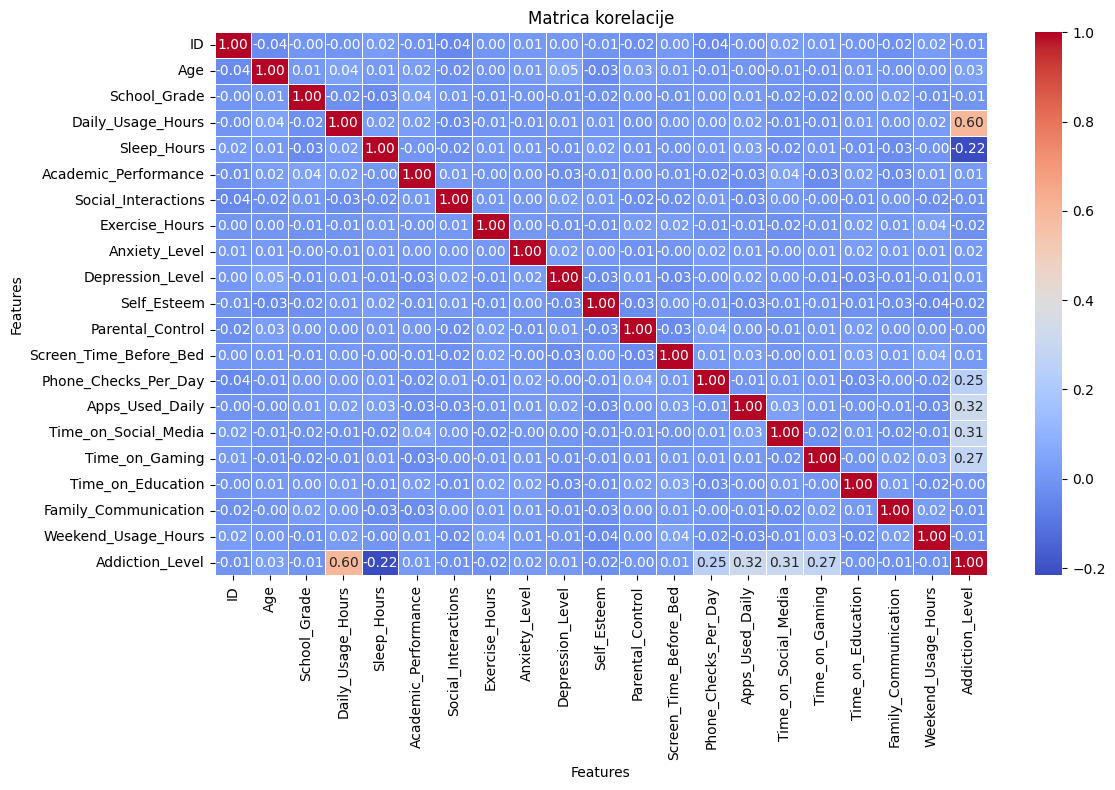

In [ ]:
# Matrica korelacije
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrica korelacije")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

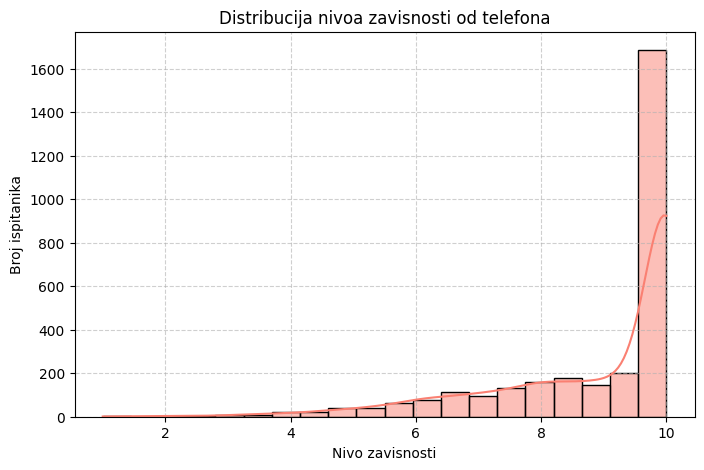

In [ ]:
# Distribucija target varijable - Addiction Level
# Distribucija nivoa zavisnosti pokazuje da je većina ispitanika u datasetu na visokom nivou zavisnosti (9–10).
# Distribucija je asimetrična i naglašena prema većim vrednostima, što može uticati na performanse modela i dovesti do pristrasnosti u predviđanju.
plt.figure(figsize=(8,5))
sns.histplot(df['Addiction_Level'], bins=20, kde=True, color='salmon')

plt.title('Distribucija nivoa zavisnosti od telefona')
plt.xlabel('Nivo zavisnosti')
plt.ylabel('Broj ispitanika')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X = df_encoded.drop(columns=['Addiction_Level', 'ID', 'Name'], errors='ignore')
y = df_encoded['Addiction_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def validate_model_with_cv(model, X_tr, y_tr, use_weights=False, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_mae_scores = []
    cv_rmse_scores = []
    cv_r2_scores = []

    for train_idx, val_idx in kf.split(X_tr):
        X_f_train, X_f_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_f_train, y_f_val = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        model_fold = model.__class__(**model.get_params())

        if use_weights:
            # linearna funkcija
            # w = 1 + (10 - y_f_train)

            # kvadratna funkcija
            # w = (10 - y_tr) ** 2

            # inverzna frekvencija
            counts = y_f_train.round().value_counts().to_dict()
            # w = y_f_train.round().apply(lambda val: 1.0 / counts.get(val, 1))
            # w = w / w.mean()

            # koren if
            # w = y_f_train.round().apply(lambda val: np.sqrt(1.0 / counts.get(val, 1)))
            # w = w / w.mean()

            # Logaritamsko ublažavanje if
            w = y_f_train.round().apply(lambda val: np.log1p(len(y_f_train) / counts.get(val, 1)))
            w = w / w.mean()

            model_fold.fit(X_f_train, y_f_train, sample_weight=w)
        else:
            model_fold.fit(X_f_train, y_f_train)

        preds_val = model_fold.predict(X_f_val)

        mae_fold = mean_absolute_error(y_f_val, preds_val)
        rmse_fold = np.sqrt(mean_squared_error(y_f_val, preds_val))
        r2_fold = r2_score(y_f_val, preds_val)

        cv_mae_scores.append(mae_fold)
        cv_rmse_scores.append(rmse_fold)
        cv_r2_scores.append(r2_fold)

    avg_mae = np.mean(cv_mae_scores)
    avg_rmse = np.mean(cv_rmse_scores)
    avg_r2 = np.mean(cv_r2_scores)

    print(f"\n===== {model.__class__.__name__} (K-Fold {'Weighted' if use_weights else 'Standard'}) =====")
    print(f"CV Prosečan MAE (Trening): {avg_mae:.4f}")
    print(f"CV Prosečan RMSE (Trening): {avg_rmse:.4f}")
    print(f"CV Prosečan R2 Score (Trening): {avg_r2:.4f}")

    return avg_mae, avg_rmse, avg_r2


def get_final_model_results(model, X_tr, y_tr, X_te, y_te, use_weights=False):
    if use_weights:

        # linearna funkcija
        # w = 1 + (10 - y_tr)

        # kvadratna funkcija
        # w = (10 - y_tr) ** 2

        # inverzna frekvencija
        counts = y_tr.round().value_counts().to_dict()
        # w = y_tr.round().apply(lambda val: 1.0 / counts.get(val, 1))
        # w = w / w.mean()

        # koren if
        # w = y_tr.round().apply(lambda val: np.sqrt(1.0 / counts.get(val, 1)))
        # w = w / w.mean()

        # Logaritamsko ublažavanje if
        w = y_tr.round().apply(lambda val: np.log1p(len(y_tr) / counts.get(val, 1)))
        w = w / w.mean()

        model.fit(X_tr, y_tr, sample_weight=w)
    else:
        model.fit(X_tr, y_tr)

    preds = model.predict(X_te)

    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)

    print(f"\n===== {model.__class__.__name__} (Finalni {'Weighted' if use_weights else 'Standard'}) =====")
    print(f"Finalni MAE (Test): {mae:.4f}")
    print(f"Finalni RMSE (Test): {rmse:.4f}")
    print(f"Finalni R2 Score (Test): {r2:.4f}")

    # DataFrame za segmentiranu analizu
    results_df = pd.DataFrame({
        "true": y_te,
        "pred": preds
    })

    return results_df


# 1. K-Fold validacija
validate_model_with_cv(LinearRegression(), X_train, y_train, use_weights=False)
validate_model_with_cv(LinearRegression(), X_train, y_train, use_weights=True)

validate_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=False)
validate_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=True)

# 2. Finalni model za segmentaciju
results_standard = get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=False)
results_weighted = get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=True)


===== LinearRegression (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.6765
CV Prosečan RMSE (Trening): 0.8428
CV Prosečan R2 Score (Trening): 0.7303

===== LinearRegression (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.7154
CV Prosečan RMSE (Trening): 0.9126
CV Prosečan R2 Score (Trening): 0.6821

===== XGBRegressor (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.3629
CV Prosečan RMSE (Trening): 0.5331
CV Prosečan R2 Score (Trening): 0.8918

===== XGBRegressor (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.3832
CV Prosečan RMSE (Trening): 0.5533
CV Prosečan R2 Score (Trening): 0.8834

===== XGBRegressor (Finalni Standard) =====
Finalni MAE (Test): 0.3500
Finalni RMSE (Test): 0.5103
Finalni R2 Score (Test): 0.8943

===== XGBRegressor (Finalni Weighted) =====
Finalni MAE (Test): 0.3515
Finalni RMSE (Test): 0.5006
Finalni R2 Score (Test): 0.8983


Broj uzoraka po segmentima:
1-6: 62
7-8: 102
9-10: 574

MAE po segmentima:
MAE (1-6): 0.7435084427556683
MAE (7-8): 0.5436938772014543
MAE (9-10): 0.24000872120209274

RMSE po segmentima:
RMSE (1-6): 0.9356939311451374
RMSE (7-8): 0.6466302121015258
RMSE (9-10): 0.36612074518020055


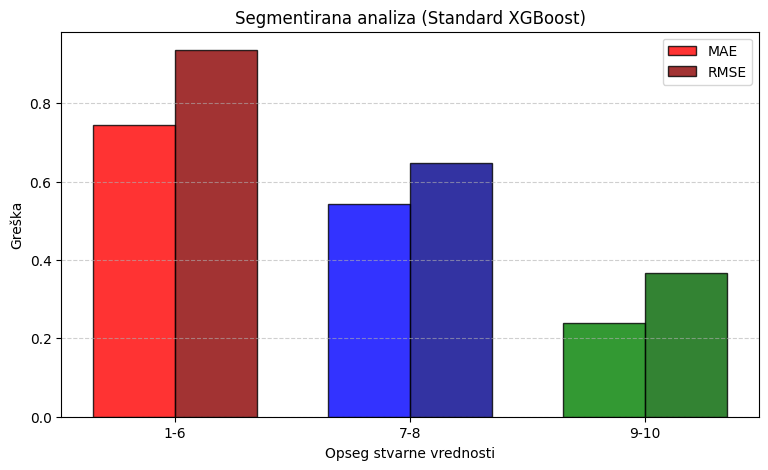

Broj uzoraka po segmentima:
1-6: 62
7-8: 102
9-10: 574

MAE po segmentima:
MAE (1-6): 0.7577198720747423
MAE (7-8): 0.4427216324151729
MAE (9-10): 0.25872426996663056

RMSE po segmentima:
RMSE (1-6): 0.9343490251123433
RMSE (7-8): 0.5634113484699871
RMSE (9-10): 0.37914790271598825


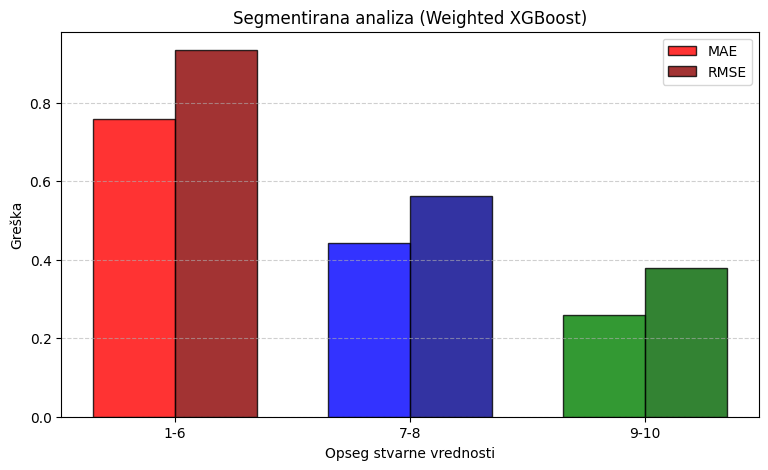

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def plot_segmented_analysis(results_df, title="Segmentirana analiza"):
    """
    Segmentirana analiza MAE i RMSE po klasama.
    Segmenti:
        low: 1-6
        mid: 7-8
        high: 9-10
    """
    # Definisanje segmenata
    low = results_df[(results_df["true"] >= 1) & (results_df["true"] <= 6)]
    mid = results_df[(results_df["true"] >= 7) & (results_df["true"] <= 8)]
    high = results_df[(results_df["true"] >= 9) & (results_df["true"] <= 10)]

    # Broj uzoraka po segmentu
    counts = [len(low), len(mid), len(high)]
    print("Broj uzoraka po segmentima:")
    print("1-6:", counts[0])
    print("7-8:", counts[1])
    print("9-10:", counts[2])

    # MAE i RMSE po segmentu
    mae_values = [
        mean_absolute_error(low["true"], low["pred"]),
        mean_absolute_error(mid["true"], mid["pred"]),
        mean_absolute_error(high["true"], high["pred"])
    ]
    rmse_values = [
        np.sqrt(mean_squared_error(low["true"], low["pred"])),
        np.sqrt(mean_squared_error(mid["true"], mid["pred"])),
        np.sqrt(mean_squared_error(high["true"], high["pred"]))
    ]
    print("\nMAE po segmentima:")
    print("MAE (1-6):", mae_values[0])
    print("MAE (7-8):", mae_values[1])
    print("MAE (9-10):", mae_values[2])

    print("\nRMSE po segmentima:")
    print("RMSE (1-6):", rmse_values[0])
    print("RMSE (7-8):", rmse_values[1])
    print("RMSE (9-10):", rmse_values[2])

    # Bar plot za MAE i RMSE
    groups = ["1-6", "7-8", "9-10"]
    colors_mae = ['red', 'blue', 'green']
    colors_rmse = ['darkred', 'darkblue', 'darkgreen']

    x = np.arange(len(groups))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9,5))
    rects1 = ax.bar(x - width/2, mae_values, width, label='MAE', color=colors_mae, edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, rmse_values, width, label='RMSE', color=colors_rmse, edgecolor='black', alpha=0.8)

    ax.set_xlabel("Opseg stvarne vrednosti")
    ax.set_ylabel("Greška")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.show()

# Standardni XGBoost
plot_segmented_analysis(results_standard, title="Segmentirana analiza (Standard XGBoost)")

# Weighted XGBoost
plot_segmented_analysis(results_weighted, title="Segmentirana analiza (Weighted XGBoost)")


MAE po segmentima (Standard XGBoost): [0.7435084427556683, 0.5436938772014543, 0.24000872120209274]
MAE po segmentima (Weighted XGBoost): [0.7577198720747423, 0.4427216324151729, 0.25872426996663056]


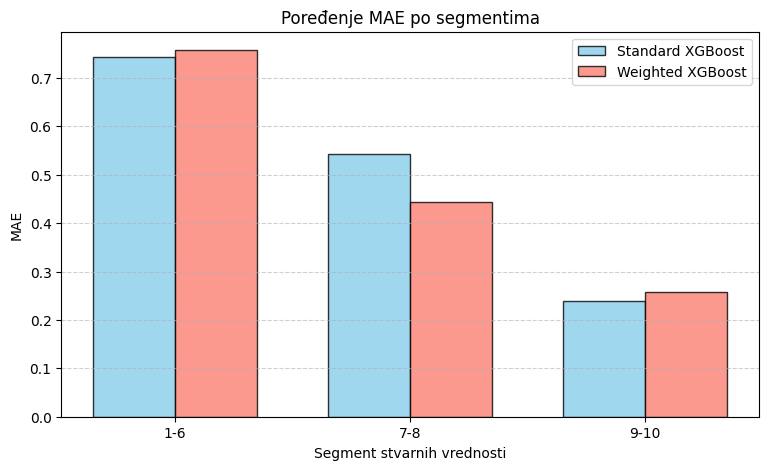

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np

def compare_segmented_mae(results1, results2, labels=("Standard", "Weighted"), title="Poređenje MAE po segmentima"):
    """
    Upoređuje MAE po segmentima za dva seta rezultata.
    results1, results2: DataFrame sa kolonama 'true' i 'pred'
    labels: imena koja će se koristiti u legendi
    """
    segments = [
        ("1-6", 1, 6),
        ("7-8", 7, 8),
        ("9-10", 9, 10)
    ]

    mae1 = []
    mae2 = []

    for seg_label, seg_min, seg_max in segments:
        seg1 = results1[(results1["true"] >= seg_min) & (results1["true"] <= seg_max)]
        seg2 = results2[(results2["true"] >= seg_min) & (results2["true"] <= seg_max)]

        mae1.append(mean_absolute_error(seg1["true"], seg1["pred"]))
        mae2.append(mean_absolute_error(seg2["true"], seg2["pred"]))

    x = np.arange(len(segments))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9,5))
    rects1 = ax.bar(x - width/2, mae1, width, label=labels[0], color='skyblue', edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, mae2, width, label=labels[1], color='salmon', edgecolor='black', alpha=0.8)

    ax.set_xlabel("Segment stvarnih vrednosti")
    ax.set_ylabel("MAE")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([seg[0] for seg in segments])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    print(f"\nMAE po segmentima ({labels[0]}): {mae1}")
    print(f"MAE po segmentima ({labels[1]}): {mae2}")

    plt.show()

# poredjenje weighted i standard
compare_segmented_mae(results_standard, results_weighted, labels=("Standard XGBoost", "Weighted XGBoost"))